**ASSIGNMENT - 2**

**Multiple Linear Regression for Predictive Analysis**

# Objective:

In this assignment, we apply Linear Regression to perform predictive analysis on the processed dataset. We prepare the input features and target variable, divide the data into training and testing sets, train a Linear Regression model, make predictions on unseen data, and evaluate the model using appropriate performance metrics.

**Import Required Libraries**

We import the libraries required for data handling, visualization, preprocessing,
Multiple Linear Regression, evaluation metrics and cross-validation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

%matplotlib inline


 **Load Dataset**

The cleaned Crop Yield Dataset is loaded for building the
Multiple Linear Regression model.

In [2]:
df = pd.read_csv("crop_yield_dataset_cleaned.csv")

print("Shape:", df.shape)

df.head()


Shape: (5000, 16)


,District,Year,Crop,Season,Area_Cultivated_Hectares,Average_Temperature_C,Total_Rainfall_mm,Humidity_Percent,Soil_Type,Soil_pH,Nitrogen_N_kg_per_ha,Phosphorus_P_kg_per_ha,Potassium_K_kg_per_ha,Irrigation_Availability,Yield_kg_per_ha,Total_Yield_kg
0,Aurangabad,2023,Bajra,Rabi,8.01,28.3,540.7,72.9,Black,6.71,106.09,61.01,29.72,Partially Irrigated,1789.90000,14338.90
1,Akola,2018,Sunflower,Kharif,43.31,24.8,577.9,45.7,Sandy,6.79,72.95,50.90,59.57,Irrigated,1782.90000,77211.00
2,Amravati,2015,Cotton,Zaid,3.32,17.3,1041.7,44.3,Red,6.67,101.64,30.87,43.34,Partially Irrigated,1611.74000,5347.81
3,Amravati,2020,Sugarcane,Zaid,21.01,28.6,1185.0,89.3,Sandy,7.36,216.15,111.79,114.61,Partially Irrigated,5971.39375,1358295.43
4,Amravati,2018,Wheat,Kharif,24.44,22.6,538.6,64.0,Loamy,6.80,119.29,87.66,38.14,Partially Irrigated,3830.25000,93629.41


The dataset contains 5,000 observations and 16 columns. It contains climate, soil, cultivation and location features that can be used for predicting crop Yield (kg per hectare).

**Dataset Information**

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   District                  5000 non-null   str    
 1   Year                      5000 non-null   int64  
 2   Crop                      5000 non-null   str    
 3   Season                    5000 non-null   str    
 4   Area_Cultivated_Hectares  5000 non-null   float64
 5   Average_Temperature_C     5000 non-null   float64
 6   Total_Rainfall_mm         5000 non-null   float64
 7   Humidity_Percent          5000 non-null   float64
 8   Soil_Type                 5000 non-null   str    
 9   Soil_pH                   5000 non-null   float64
 10  Nitrogen_N_kg_per_ha      5000 non-null   float64
 11  Phosphorus_P_kg_per_ha    5000 non-null   float64
 12  Potassium_K_kg_per_ha     5000 non-null   float64
 13  Irrigation_Availability   5000 non-null   str    
 14  Yield_kg_per_ha    

**Statistical Summary**

In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Year,5000.0,2019.529200,2.881737,2015.00000,2017.0000,2020.000,2022.0000,2.024000e+03
Area_Cultivated_Hectares,5000.0,25.698575,14.180563,0.02290,13.5475,25.740,37.8000,7.417875e+01
Average_Temperature_C,5000.0,26.759720,4.860479,14.25000,23.7000,26.900,30.0000,3.945000e+01
Total_Rainfall_mm,5000.0,715.713745,329.493359,0.36240,486.1250,610.700,834.6750,1.357500e+03
Humidity_Percent,5000.0,64.660660,13.996785,40.00000,52.9000,64.600,76.5000,9.000000e+01
Soil_pH,5000.0,6.724962,0.570157,4.61000,6.3500,6.730,7.0900,9.000000e+00
Nitrogen_N_kg_per_ha,5000.0,85.298488,52.850938,3.59000,46.9675,76.200,107.8300,3.783800e+02
Phosphorus_P_kg_per_ha,5000.0,53.029598,20.516969,0.00000,39.1900,50.170,63.7175,1.441300e+02
Potassium_K_kg_per_ha,5000.0,51.501548,24.682894,0.00000,34.5300,47.310,62.9125,1.918300e+02
Yield_kg_per_ha,5000.0,2690.653351,1483.168611,-1016.67625,1603.8500,2169.745,3350.8675,5.971394e+03


**Check Missing Values**

In [5]:
print("Missing values in each column:")
print(df.isnull().sum())


Missing values in each column:
District                    0
Year                        0
Crop                        0
Season                      0
Area_Cultivated_Hectares    0
Average_Temperature_C       0
Total_Rainfall_mm           0
Humidity_Percent            0
Soil_Type                   0
Soil_pH                     0
Nitrogen_N_kg_per_ha        0
Phosphorus_P_kg_per_ha      0
Potassium_K_kg_per_ha       0
Irrigation_Availability     0
Yield_kg_per_ha             0
Total_Yield_kg              0
dtype: int64


In [6]:
print("Total missing values:", df.isnull().sum().sum())


Total missing values: 0


The dataset has zero missing values since it was already cleaned and imputed in the preprocessing stage.

**Encode Categorical Variables**

The dataset contains categorical columns (`District`, `Crop`, `Season`, `Soil_Type`, `Irrigation_Availability`) that must be converted to numeric form before they can be used in a regression model. We use one-hot encoding, which creates a separate binary column for each category instead of assigning an arbitrary numeric order.

In [7]:
categorical_cols = ["District", "Crop", "Season", "Soil_Type", "Irrigation_Availability"]

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Shape after encoding:", df_encoded.shape)

df_encoded.head()


Shape after encoding: (5000, 43)


,Year,Area_Cultivated_Hectares,Average_Temperature_C,Total_Rainfall_mm,Humidity_Percent,Soil_pH,Nitrogen_N_kg_per_ha,Phosphorus_P_kg_per_ha,Potassium_K_kg_per_ha,Yield_kg_per_ha,Total_Yield_kg,District_Akola,District_Amravati,District_Aurangabad,District_Dhule,District_Jalgaon,District_Kolhapur,District_Nagpur,District_Nashik,District_Pune,District_Sangli,District_Satara,District_Solapur,District_Wardha,District_Yavatmal,Crop_Cotton,Crop_Groundnut,Crop_Jowar,Crop_Maize,Crop_Rice,Crop_Soybean,Crop_Sugarcane,Crop_Sunflower,Crop_Wheat,Season_Rabi,Season_Zaid,Soil_Type_Clayey,Soil_Type_Laterite,Soil_Type_Loamy,Soil_Type_Red,Soil_Type_Sandy,Irrigation_Availability_Partially Irrigated,Irrigation_Availability_Rainfed
0,2023,8.01,28.3,540.7,72.9,6.71,106.09,61.01,29.72,1789.90000,14338.90,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False
1,2018,43.31,24.8,577.9,45.7,6.79,72.95,50.90,59.57,1782.90000,77211.00,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False
2,2015,3.32,17.3,1041.7,44.3,6.67,101.64,30.87,43.34,1611.74000,5347.81,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False
3,2020,21.01,28.6,1185.0,89.3,7.36,216.15,111.79,114.61,5971.39375,1358295.43,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,True,False
4,2018,24.44,22.6,538.6,64.0,6.80,119.29,87.66,38.14,3830.25000,93629.41,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False


**Define Features and Target**

In [8]:
feature_cols = [
    col for col in df_encoded.columns
    if col not in ["Yield_kg_per_ha", "Total_Yield_kg"]
]

target_col = "Yield_kg_per_ha"

X = df_encoded[feature_cols]
y = df_encoded[target_col]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)


Feature matrix shape: (5000, 41)
Target shape: (5000,)


In [9]:
X.head()


,Year,Area_Cultivated_Hectares,Average_Temperature_C,Total_Rainfall_mm,Humidity_Percent,Soil_pH,Nitrogen_N_kg_per_ha,Phosphorus_P_kg_per_ha,Potassium_K_kg_per_ha,District_Akola,District_Amravati,District_Aurangabad,District_Dhule,District_Jalgaon,District_Kolhapur,District_Nagpur,District_Nashik,District_Pune,District_Sangli,District_Satara,District_Solapur,District_Wardha,District_Yavatmal,Crop_Cotton,Crop_Groundnut,Crop_Jowar,Crop_Maize,Crop_Rice,Crop_Soybean,Crop_Sugarcane,Crop_Sunflower,Crop_Wheat,Season_Rabi,Season_Zaid,Soil_Type_Clayey,Soil_Type_Laterite,Soil_Type_Loamy,Soil_Type_Red,Soil_Type_Sandy,Irrigation_Availability_Partially Irrigated,Irrigation_Availability_Rainfed
0,2023,8.01,28.3,540.7,72.9,6.71,106.09,61.01,29.72,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False
1,2018,43.31,24.8,577.9,45.7,6.79,72.95,50.90,59.57,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False
2,2015,3.32,17.3,1041.7,44.3,6.67,101.64,30.87,43.34,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False
3,2020,21.01,28.6,1185.0,89.3,7.36,216.15,111.79,114.61,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,True,False
4,2018,24.44,22.6,538.6,64.0,6.80,119.29,87.66,38.14,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False


The input feature matrix X contains 41 columns (numeric features plus one-hot encoded categorical variables), while y contains the target variable Yield_kg_per_ha.

**Features Excluded**

The column `Total_Yield_kg` is excluded because it is directly derived from
`Yield_kg_per_ha × Area_Cultivated_Hectares`. Including it would leak the
target variable into the input features and produce an artificially perfect
model that would not generalize to new data.

**Train-Test Split**

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)


Training set: (4000, 41)
Test set: (1000, 41)


The data is divided into 4,000 training samples and 1,000 testing samples, with 41 input features in each set.

**Feature Scaling**

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print(
    "Train mean:",
    np.round(X_train_scaled.mean(axis=0), 3)
)

print(
    "Train std:",
    np.round(X_train_scaled.std(axis=0), 3)
)


Train mean: [-0. -0.  0. -0.  0.  0. -0. -0. -0. -0. -0. -0. -0.  0.  0. -0.  0.  0.
 -0.  0. -0. -0.  0.  0.  0. -0.  0. -0. -0. -0.  0. -0.  0.  0.  0.  0.
 -0. -0.  0. -0.  0.]
Train std: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


The training features are standardized using the mean and standard deviation calculated from the training data. The same transformation is then applied to the testing data.

**Create Multiple Linear Regression Model**

In [12]:
lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

y_pred = lr_model.predict(X_test_scaled)


A Multiple Linear Regression model is successfully initialized and is ready for training.

**Calculate Evaluation Metrics**

In [13]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

r2_train = r2_score(
    y_train,
    lr_model.predict(X_train_scaled)
)

print(f"MAE       : {mae:.4f}")
print(f"MSE       : {mse:.4f}")
print(f"RMSE      : {rmse:.4f}")
print(f"R² (test) : {r2:.4f}")
print(f"R² (train): {r2_train:.4f}")


MAE       : 321.5510
MSE       : 192952.9299
RMSE      : 439.2641
R² (test) : 0.9130
R² (train): 0.8960


MAE: average absolute prediction error in kg/ha.

MSE: average squared prediction error.

RMSE: error in the same unit as Yield, kg/ha.

R²: proportion of variation in Yield explained by the model.

The model explains roughly 91% of the variance in yield on the test set
(R² ≈ 0.91), with the train and test R² close to each other, indicating the
model is not overfitting.

**Actual vs Predicted Yield**

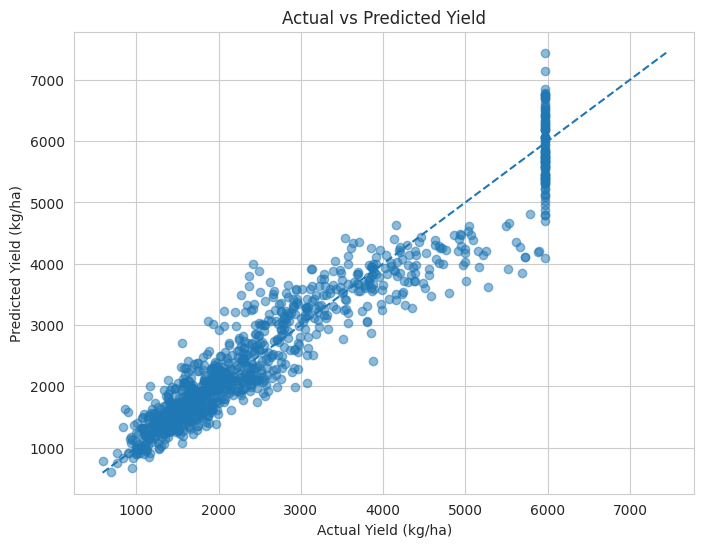

In [14]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Yield (kg/ha)")
plt.ylabel("Predicted Yield (kg/ha)")
plt.title("Actual vs Predicted Yield")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.show()


Most points are distributed close to the diagonal reference line, indicating that the predicted Yield values are generally close to the actual Yield values.

**Calculate Residuals**

In [15]:
residuals = y_test - y_pred

print("Residual Mean:", residuals.mean())
print("Residual Standard Deviation:", residuals.std())


Residual Mean: -2.103781285913303
Residual Standard Deviation: 439.47883408671834


The residuals are calculated to analyze the prediction errors of the regression model. The mean and standard deviation of the residuals are also examined.

**Residuals vs Predicted Values**

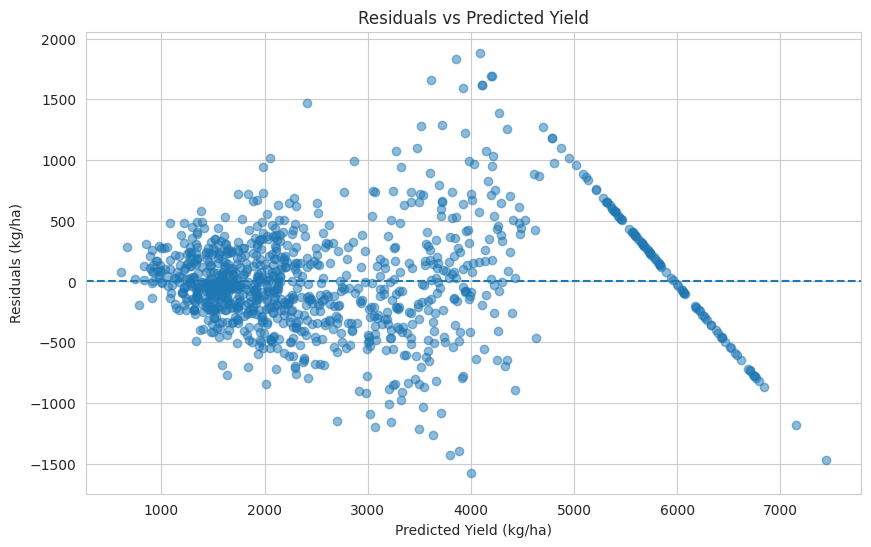

In [16]:
plt.figure(figsize=(10, 6))

plt.scatter(y_pred, residuals, alpha=0.5)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Yield (kg/ha)")
plt.ylabel("Residuals (kg/ha)")
plt.title("Residuals vs Predicted Yield")

plt.show()


The residuals are distributed around the zero line without a strong systematic pattern. This suggests that the regression model captures a substantial part of the relationship between the features and Yield, satisfying the linearity assumption reasonably well.

**Distribution of Regression Residuals**

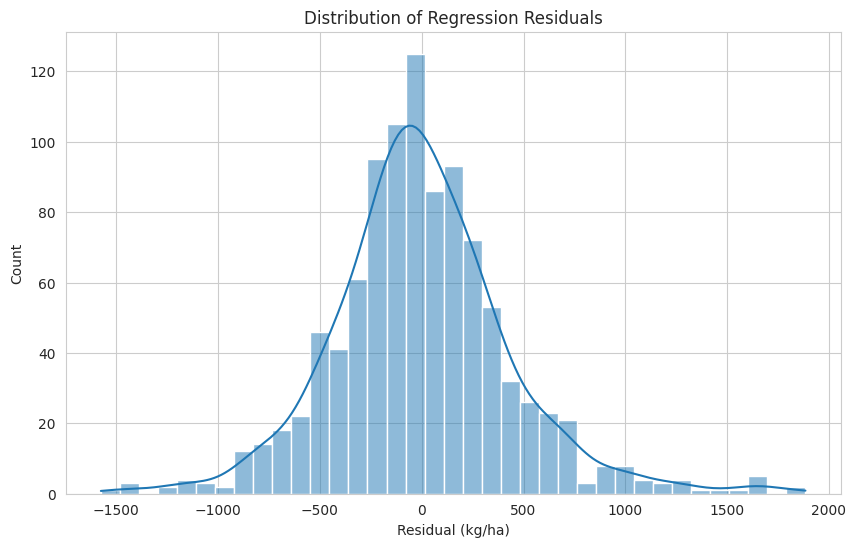

In [17]:
plt.figure(figsize=(10, 6))

sns.histplot(residuals, kde=True)

plt.xlabel("Residual (kg/ha)")
plt.title("Distribution of Regression Residuals")

plt.show()


The residual distribution is centered approximately around zero and appears approximately bell-shaped, indicating that most prediction errors are relatively small and centered around zero, which supports the normality assumption of the residuals.

**Regression Coefficients**

In [18]:
coefficients = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": lr_model.coef_
})

coefficients["Absolute_Coefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

coefficients


,Feature,Coefficient,Absolute_Coefficient
29,Crop_Sugarcane,750.831229,750.831229
27,Crop_Rice,548.756860,548.756860
26,Crop_Maize,417.805362,417.805362
40,Irrigation_Availability_Rainfed,-310.894878,310.894878
6,Nitrogen_N_kg_per_ha,287.416480,287.416480
7,Phosphorus_P_kg_per_ha,230.337074,230.337074
30,Crop_Sunflower,-210.786685,210.786685
8,Potassium_K_kg_per_ha,210.690479,210.690479
31,Crop_Wheat,206.664739,206.664739
39,Irrigation_Availability_Partially Irrigated,-164.645636,164.645636


The coefficients show how each feature contributes to the predicted Yield while the other features are considered in the model. Positive coefficients indicate a positive relationship with predicted Yield, while negative coefficients indicate a negative relationship.

**Top 15 Regression Coefficients**

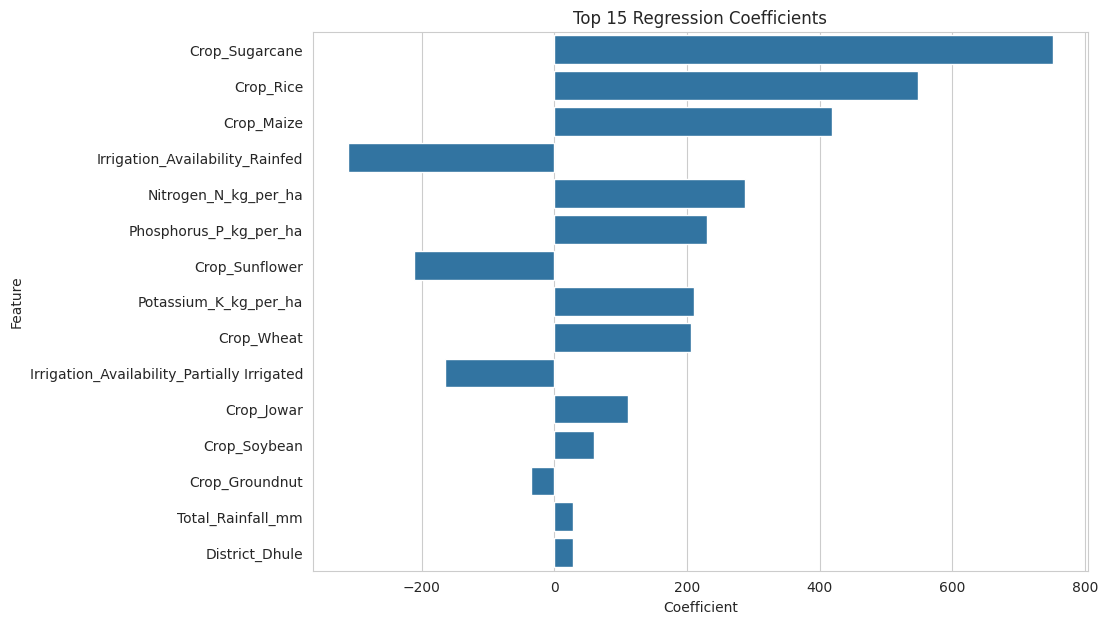

In [19]:
top_coefficients = coefficients.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_coefficients,
    x="Coefficient",
    y="Feature"
)

plt.title("Top 15 Regression Coefficients")

plt.show()


The crop type (particularly Sugarcane, Rice and Maize) has the largest coefficients among the displayed features, meaning the choice of crop is the strongest driver of predicted yield. Irrigation availability and nutrient levels (Nitrogen, Phosphorus, Potassium) also show sizeable effects, while climate variables like rainfall have a comparatively smaller effect. This provides an interpretation of the model's learned relationships.

**5-Fold Cross Validation**

In [20]:
cv_scores = cross_val_score(
    lr_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="r2"
)

print("5-Fold Cross-Validation R² Scores:")
print(cv_scores)

print("\nMean CV R²:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())


5-Fold Cross-Validation R² Scores:
[0.9013376  0.88778011 0.88131766 0.90606932 0.89009804]

Mean CV R²: 0.8933205452400463
Standard Deviation: 0.009076945629832087


The model is evaluated across five different folds. The individual R² scores are consistently around 0.88–0.91, with a mean CV R² of approximately 0.89 and a small standard deviation, indicating stable and consistent model performance across different subsets of the training data.

**Compare Actual and Predicted Values**

In [21]:
comparison = pd.DataFrame({
    "Actual_Yield": y_test.values,
    "Predicted_Yield": y_pred
})

comparison["Error"] = (
    comparison["Actual_Yield"] -
    comparison["Predicted_Yield"]
)

comparison.head(20)


,Actual_Yield,Predicted_Yield,Error
0,2930.19000,3184.094864,-253.904864
1,1547.80000,1746.406804,-198.606804
2,5043.99000,4618.435470,425.554530
3,2779.04000,2877.357415,-98.317415
4,4368.39000,3953.185680,415.204320
5,1383.51000,1879.786027,-496.276027
6,1412.26000,1257.232726,155.027274
7,2195.70000,3207.288363,-1011.588363
8,2019.22000,1890.256510,128.963490
9,5971.39375,5681.305300,290.088450


The comparison table shows that the predicted Yield values are generally close to the actual Yield values, while the Error column represents the difference between the actual and predicted values.

**Prediction Error Plot**

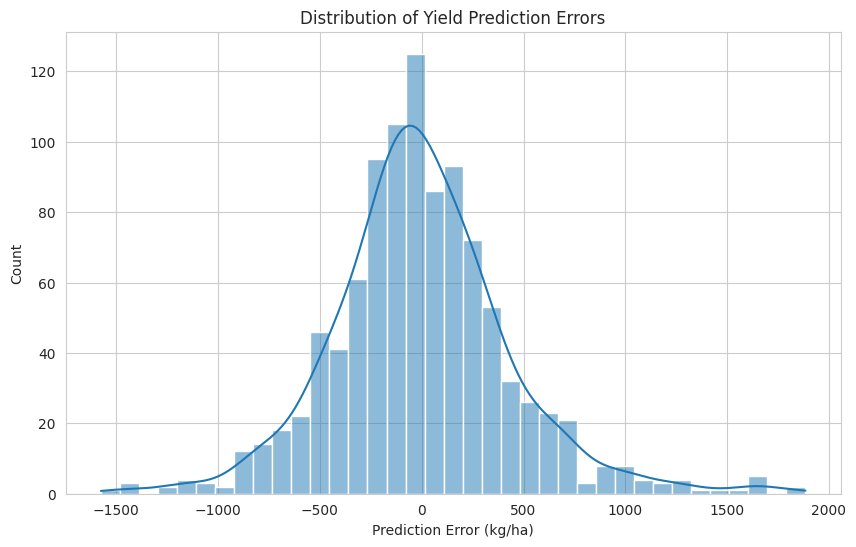

In [22]:
plt.figure(figsize=(10, 6))

sns.histplot(
    comparison["Error"],
    kde=True
)

plt.xlabel("Prediction Error (kg/ha)")
plt.title("Distribution of Yield Prediction Errors")

plt.show()


The prediction errors are distributed around zero, with most errors relatively small and some observations showing larger positive or negative errors.

**Final Model Summary**

In [23]:
print("========== LINEAR REGRESSION SUMMARY ==========")

print(f"Number of observations : {len(df)}")
print(f"Number of features     : {len(feature_cols)}")
print(f"Training observations  : {len(X_train)}")
print(f"Testing observations   : {len(X_test)}")

print(f"\nMAE       : {mae:.4f} kg/ha")
print(f"MSE       : {mse:.4f}")
print(f"RMSE      : {rmse:.4f} kg/ha")
print(f"Test R²   : {r2:.4f}")
print(f"Train R²  : {r2_train:.4f}")

print(f"\nMean CV R²: {cv_scores.mean():.4f}")


========== LINEAR REGRESSION SUMMARY ==========
Number of observations : 5000
Number of features     : 41
Training observations  : 4000
Testing observations   : 1000

MAE       : 321.5510 kg/ha
MSE       : 192952.9299
RMSE      : 439.2641 kg/ha
Test R²   : 0.9130
Train R²  : 0.8960

Mean CV R²: 0.8933


**Conclusion**

In Assignment 2, we successfully developed a Multiple Linear Regression model to predict crop Yield using climate, soil, cultivation and location features from the crop yield dataset. We first inspected and prepared the dataset, encoded the categorical variables, separated the input features and Yield target, and excluded the derived `Total_Yield_kg` column to prevent target leakage. The features were standardized, and the data was split into training and testing sets. The trained model achieved an R² of approximately 0.91 on the test set and a consistent mean cross-validation R² of approximately 0.89, indicating that it generalizes well and is not overfitting. The residual plots showed errors scattered around zero without strong patterns, supporting the linearity and normality assumptions of the model. The regression coefficients revealed that crop type, irrigation availability and nutrient levels (Nitrogen, Phosphorus, Potassium) are the strongest drivers of predicted yield. Overall, Linear Regression proved to be an effective and interpretable model for this predictive analysis task.